# REINFORCE Small Language Model Credit Assignment

## Objective

In this assignment, you implement the REINFORCE algorithm from scratch and apply it to a small autoregressive character-level language model.

The goal is to understand **temporal credit assignment**: how token decisions made *early* in a sequence receive gradient signal from a reward observed only at the *end* of the sequence.

## Setup

### Vocabulary

We use 5 tokens: `<bos>`, `a`, `b`, `c`, `<eos>`.

The model always starts from `<bos>` (so no token of the actual sequence is forced) and may emit `<eos>` to terminate.

### Reward

The reward is given **only at the end** of the trajectory:

$$R(\tau) = \begin{cases} 1 & \text{if the substring } \texttt{abc} \text{ appears in the sampled sequence} \\ 0 & \text{otherwise} \end{cases}$$

This requires **three correct decisions in a row** (`a` after `<bos>`, then `b`, then `c`), which makes per-timestep credit assignment non-trivial.


In [ ]:
# pip install torch matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

vocab = ['<bos>', 'a', 'b', 'c', '<eos>']
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(vocab)


## Task 1: Policy network

Implement a memoryless character-level policy $\pi_\theta(a_t \mid a_{t-1})$.

Requirements:
- `nn.Embedding(vocab_size, d)` with `d = 8`
- `nn.Linear(d, vocab_size)` producing logits (do **not** apply softmax inside `forward` — sampling will use `Categorical` directly on logits or on softmaxed probs)

> **Note on memorylessness.** Because each conditioning context (`<bos>`, `a`, `b`, `c`) maps to a *different* desired next token, a memoryless model is sufficient to reach optimal reward.

In [ ]:
class CharPolicy(nn.Module):
    def __init__(self, embed_dim: int = 8):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.embedding(x)
        logits = self.linear(emb)
        return logits

## Task 2: Sampling

Implement trajectory sampling from the policy.

Specification:
- Start from `<bos>` (this token is **not** included in the returned sequence and contributes **no** log-prob).
- At each step, sample the next token from `Categorical(logits=...)`.
- Stop when `<eos>` is sampled or `max_len` tokens have been produced.
- The log-prob of the sampled `<eos>` (if any) **is** included — the decision to stop is part of the policy.

Return type: `tuple[list[str], torch.Tensor]`
- `seq`: list of token strings actually sampled (may include `<eos>` as the last element)
- `log_probs`: 1-D tensor of shape `[T]` where `T = len(seq)`


In [ ]:
from torch.distributions import Categorical

def sample(model: CharPolicy, max_len: int = 8) -> tuple[list[str], torch.Tensor]:

    seq = []
    log_probs = []

    current_token = torch.tensor([stoi['<bos>']])

    for _ in range(max_len):

        logits = model(current_token)

        dist = Categorical(logits=logits)

        next_token = dist.sample()

        log_prob = dist.log_prob(next_token)

        token_id = next_token.item()
        token_str = itos[token_id]

        seq.append(token_str)
        log_probs.append(log_prob)

        if token_str == '<eos>':
            break

        current_token = next_token

    return seq, torch.stack(log_probs)

## Task 3: Reward

Implement the terminal reward:

$$R(\tau) = \begin{cases} 1 & \text{if "abc" appears as a substring of } \tau \\ 0 & \text{otherwise} \end{cases}$$

In [ ]:
def reward(seq: list[str]) -> float:

    joined = ''.join(seq)

    if 'abc' in joined:
        return 1.0

    return 0.0

## Task 4: REINFORCE update (no baseline)

The policy gradient theorem with terminal-only reward gives:

$$\nabla_\theta J(\theta) = \mathbb{E}_\tau \left[ \sum_{t=1}^{T} G_t \, \nabla_\theta \log \pi_\theta(a_t \mid a_{<t}) \right], \qquad G_t = R(\tau)$$

The corresponding loss for a single sampled trajectory is:

$$\mathcal{L}(\theta) = -R(\tau) \sum_{t=1}^{T} \log \pi_\theta(a_t \mid a_{<t})$$

Implement the training loop:
1. Sample one trajectory.
2. Compute `R`.
3. Compute `loss` per the formula above.
4. `optimizer.zero_grad(); loss.backward(); optimizer.step()`.
5. Track the running average reward and plot it at the end.

Run for **1500** steps. (Cold-start exploration is hard here; without a baseline some seeds may fail to converge — this is exactly the problem Task 4b addresses.)


In [ ]:
torch.manual_seed(0)

model = CharPolicy()

optimizer = optim.Adam(model.parameters(), lr=1e-2)

rewards_no_baseline = []

for step in range(1500):

    seq, log_probs = sample(model)

    R = reward(seq)

    loss = -R * log_probs.sum()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    rewards_no_baseline.append(R)

In [ ]:
def moving_average(data, window=50):

    averages = []

    for i in range(len(data)):

        start = max(0, i - window + 1)

        averages.append(sum(data[start:i+1]) / (i - start + 1))

    return averages

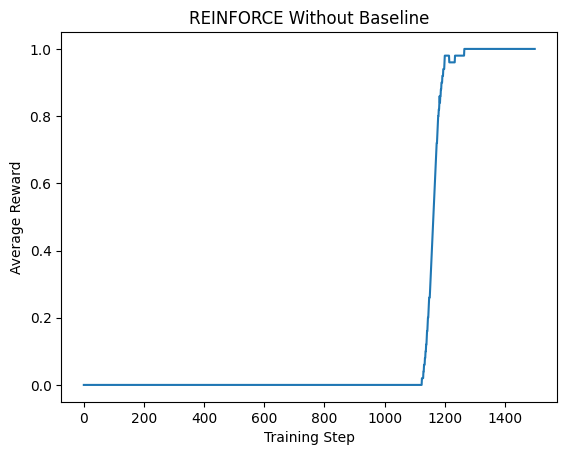

In [ ]:
plt.plot(moving_average(rewards_no_baseline))
plt.xlabel("Training Step")
plt.ylabel("Average Reward")
plt.title("REINFORCE Without Baseline")
plt.show()

## Task 4b: REINFORCE with a running-mean baseline

The variance of the gradient estimator above is high — half your updates have `R = 0` and produce no gradient. Subtracting a *baseline* `b(s)` that does not depend on the action leaves the gradient unbiased while reducing variance:

$$\mathcal{L}(\theta) = -(R(\tau) - b) \sum_{t} \log \pi_\theta(a_t \mid a_{<t})$$

A simple choice is an exponential moving average of recent returns:

```python
b = 0.9 * b + 0.1 * R
```

Re-train a fresh model with this baseline, log rewards into `rewards_with_baseline`, and plot **both** curves on the same axes. You should see the baselined run reach R≈1 noticeably faster and with less wiggle.


In [ ]:
torch.manual_seed(0)

model = CharPolicy()

optimizer = optim.Adam(model.parameters(), lr=1e-2)

rewards_with_baseline: list[float] = []

baseline = 0.0

for step in range(1500):

    seq, log_probs = sample(model)

    R = reward(seq)

    advantage = R - baseline

    loss = -advantage * log_probs.sum()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    baseline = 0.9 * baseline + 0.1 * R

    rewards_with_baseline.append(R)

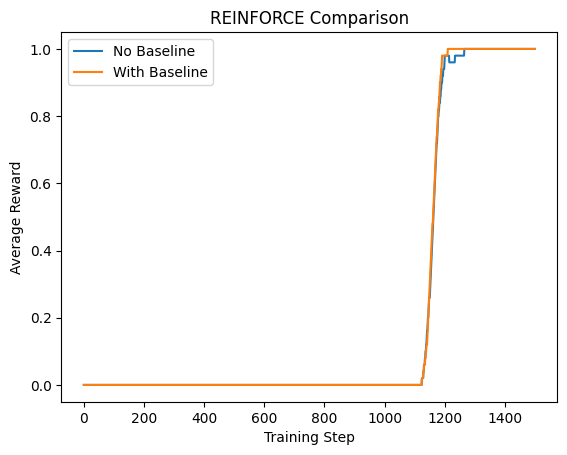

In [ ]:
plt.plot(moving_average(rewards_no_baseline), label="No Baseline")

plt.plot(moving_average(rewards_with_baseline), label="With Baseline")

plt.xlabel("Training Step")

plt.ylabel("Average Reward")

plt.title("REINFORCE Comparison")

plt.legend()

plt.show()

## Task 5: Credit assignment analysis

Answer the following using the **trained baselined model**.

### 5a. Inspect the learned conditional distributions

Print $\pi_\theta(\cdot \mid x)$ for each $x \in \{\texttt{<bos>}, \texttt{a}, \texttt{b}, \texttt{c}\}$. You should see:

- $\pi(\texttt{a} \mid \texttt{<bos>}) \approx 1$
- $\pi(\texttt{b} \mid \texttt{a}) \approx 1$
- $\pi(\texttt{c} \mid \texttt{b}) \approx 1$
- $\pi(\texttt{<eos>} \mid \texttt{c}) \approx 1$

### 5b. Sample 10 trajectories from the trained model

Print each sampled sequence and its reward.

### 5c. Discussion (3–5 sentences)

Explain, in your own words, why the very first decision $\pi(\cdot \mid \texttt{<bos>})$ ever receives any gradient signal at all, despite the reward being observed only after $\texttt{c}$ is emitted. Reference the term $R(\tau) \cdot \log \pi(a_1 \mid \texttt{<bos>})$ in the loss explicitly.

In [ ]:
with torch.no_grad():
    for ctx in ['<bos>', 'a', 'b', 'c']:
        x = torch.tensor([stoi[ctx]])
        probs = torch.softmax(model(x), dim=-1).squeeze()

        print(f"\nGiven: {ctx}")
        for token, prob in zip(vocab, probs):
            print(f"  P({token} | {ctx}) = {prob.item():.4f}")


Given: <bos>
  P(<bos> | <bos>) = 0.0016
  P(a | <bos>) = 0.9918
  P(b | <bos>) = 0.0024
  P(c | <bos>) = 0.0009
  P(<eos> | <bos>) = 0.0032

Given: a
  P(<bos> | a) = 0.1018
  P(a | a) = 0.0025
  P(b | a) = 0.8918
  P(c | a) = 0.0015
  P(<eos> | a) = 0.0025

Given: b
  P(<bos> | b) = 0.0003
  P(a | b) = 0.0001
  P(b | b) = 0.0001
  P(c | b) = 0.9992
  P(<eos> | b) = 0.0003

Given: c
  P(<bos> | c) = 0.4949
  P(a | c) = 0.0616
  P(b | c) = 0.1802
  P(c | c) = 0.1748
  P(<eos> | c) = 0.0885


In [ ]:
for i in range(10):
    seq, log_probs = sample(model)
    R = reward(seq)
    print(f"{i+1}: {seq}, reward = {R}")

1: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b'], reward = 1.0
2: ['a', 'b', 'c', 'b', 'c', 'b', 'c', '<bos>'], reward = 1.0
3: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b'], reward = 1.0
4: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>'], reward = 1.0
5: ['a', 'b', 'c', 'c', 'c', 'b', 'c', 'c'], reward = 1.0
6: ['a', 'b', 'c', 'b', 'c', '<bos>', 'a', 'b'], reward = 1.0
7: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b'], reward = 1.0
8: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>'], reward = 1.0
9: ['a', 'b', 'c', 'b', 'c', '<bos>', 'a', 'b'], reward = 1.0
10: ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'c'], reward = 1.0


#5c)
Even though the reward is only observed at the end of the sequence, the first decision still receives gradient signal because the REINFORCE loss included the term R(τ) * logπ(a1 | <bos>). This means that when a sample trajectory successfully contains the substring "abc" and receives reward 1, the model reinforces all actions taht contributed to that successful suquence, including the very first token choice. Over many training smaples, the model learns that choosing "a" after <bos> increases the likelihood of eventually receiving rewards.This successfully demonstrates temporal credit assignment where early actions are rewards based on outcomes observed later in the trajectory.